# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [5]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun

In [6]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [7]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [ ]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [9]:
data

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6805395,10777,-1,27,15,23,0.000210,-1,0.093303,0
6805396,10777,-1,27,21,23,0.000190,-1,0.087002,0
6805397,10777,-1,27,23,9,0.000216,-1,0.069199,0
6805398,10777,-1,27,24,9,0.000611,-1,0.083242,0


### Get the deconv data (share the energy)

In [ ]:
datadeco   = evtfun.get_deconvoluted_data(data)
#evtfun.test_get_deconvoluted_data(data)
datadeco = datadeco[datadeco.decopred == 1].copy()

## Display an event

In [103]:
ievent   = 23

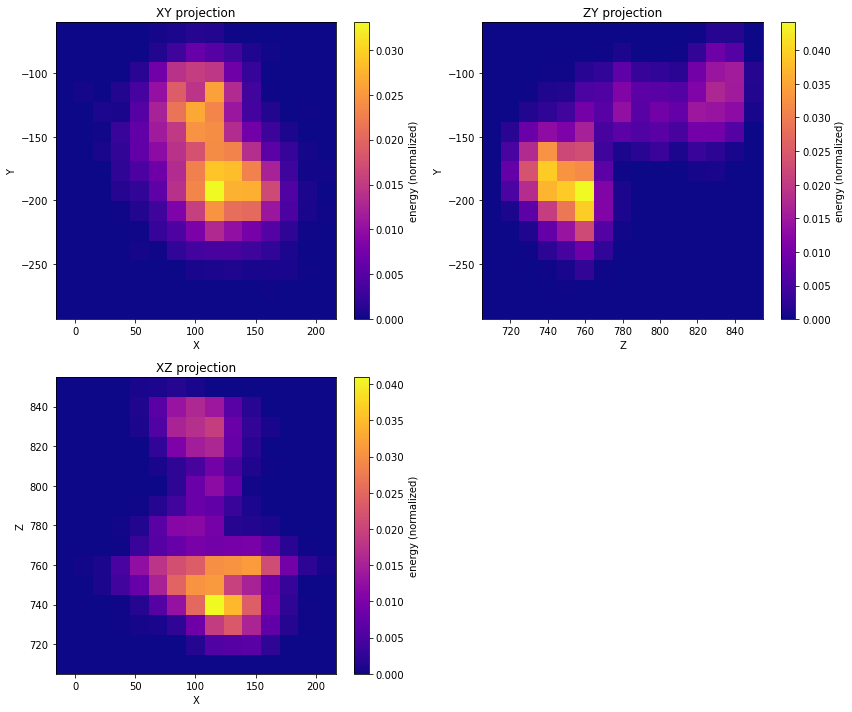

In [104]:
evt   = data.groupby('dataset_id').get_group(ievent)
coors = evtfun.get_coors(evt, bin_info)
bins  = evtfun.get_bins(coors, bin_widths)
ene   = evt.energy.values 
evtfun.event_display(coors, bins, ene = ene);


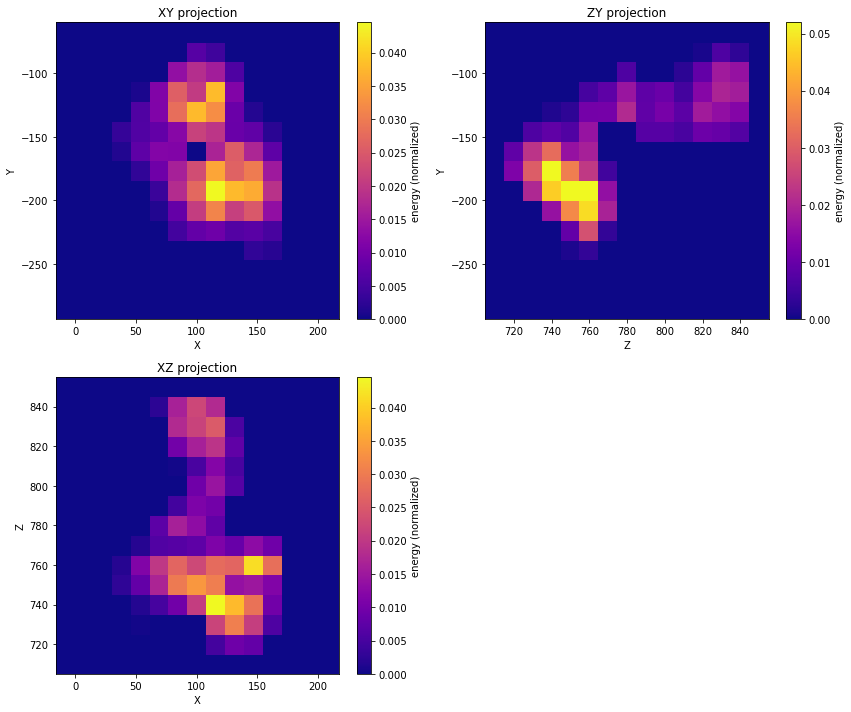

In [105]:
#evtdeco   = evtfun.get_deconvoluted_data(evt)
evtdeco   = datadeco.groupby('dataset_id').get_group(ievent)
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
enedeco   = evtdeco.enecn.values
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);

In [106]:
print(f" total corrected and normalized energy of deco hits = ", evtdeco.enecn.sum(),
       "\n total corrected energy en slices with decho hits = ", evtdeco.enecc.sum(),
       "\n total original energy of the deco hits = ", evtdeco.energy.sum())

 total corrected and normalized energy of deco hits =  1.0 
 total corrected energy en slices with decho hits =  0.9961200580000876 
 total original energy of the deco hits =  0.6888104


## Display graph

In [107]:
graph                      = graphfun.convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
componentes, longest_graph = graphfun.graph_connectivity(graph)
_, longest_graph2          = graphfun.graph_connectivity(longest_graph)

[(-1, -1, -1), (-1, -1, 0), (-1, -1, 1), (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), (-1, 1, -1), (-1, 1, 0), (-1, 1, 1), (0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (0, 0, 0), (0, 0, 1), (0, 1, -1), (0, 1, 0), (0, 1, 1), (1, -1, -1), (1, -1, 0), (1, -1, 1), (1, 0, -1), (1, 0, 0), (1, 0, 1), (1, 1, -1), (1, 1, 0), (1, 1, 1)]
Is graph conected?  True
Number of components: 1
Component 1: {(7, 10, 10), (8, 6, 6), (4, 10, 5), (11, 3, 4), (10, 4, 5), (9, 8, 3), (7, 11, 5), (7, 9, 10), (7, 10, 8), (9, 6, 5), (8, 11, 11), (4, 7, 4), (7, 9, 8), (7, 11, 7), (9, 8, 1), (11, 8, 2), (8, 6, 2), (11, 6, 5), (8, 11, 9), (5, 10, 4), (11, 6, 3), (5, 5, 5), (11, 8, 4), (6, 10, 13), (5, 10, 6), (7, 9, 12), (6, 10, 11), (6, 5, 5), (9, 6, 3), (8, 11, 13), (3, 8, 4), (9, 11, 11), (7, 12, 12), (11, 9, 5), (6, 6, 3), (7, 11, 13), (7, 4, 5), (8, 8, 3), (8, 13, 12), (9, 11, 9), (11, 5, 5), (11, 9, 3), (7, 5, 6), (6, 10, 7), (8, 5, 5), (6, 11, 6), (10, 9, 5), (3, 9, 5), (6, 12, 7), (10, 7, 2), (7, 11, 9), (7, 5, 4

extremes distance: 14 , extrenes nodes: (6, 9, 13) (10, 3, 4)
extremes distance: 14 , extrenes nodes: (5, 11, 13) (10, 3, 4)


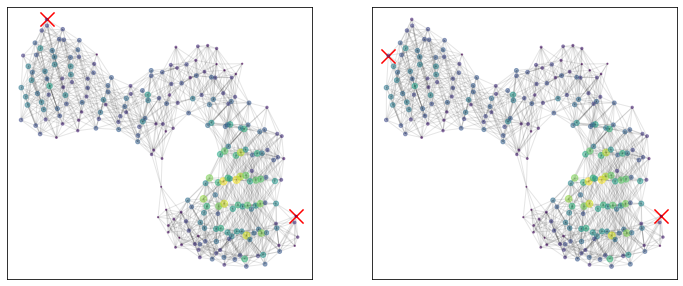

In [108]:
cv = pltext.canvas(2, 2)
cv(1)
u, v, dist = graphfun.graph_extremes(graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(graph, (u, v))
cv(2)
u, v, dist = graphfun.graph_extremes(longest_graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(longest_graph, (u, v))

## Get Blobs

In [ ]:
def get_blobs(graph, u, v, distance):
    blobs     = [graphfun.subgraph_within_distance(longest_graph, x, distance) for x in (u, v)]
    blobs_ene = [graphfun.graph_total_weight(blob) for blob in blobs]
    if blobs_ene[0] < blobs_ene[1]:
        blobs     = blobs[::-1]
        blobs_ene = blobs_ene[::-1]
    blobs_bc  = [graphfun.graph_barycenter(blob) for blob in blobs]
    return blobs, blobs_ene, blobs_bc

In [ ]:
distance = 3
blobs     = [graphfun.subgraph_within_distance(longest_graph, x, distance) for x in (u, v)]
blobs_ene = [graphfun.graph_total_weight(blob) for blob in blobs]
blobs_bc  = [graphfun.graph_barycenter(blob) for blob in blobs]

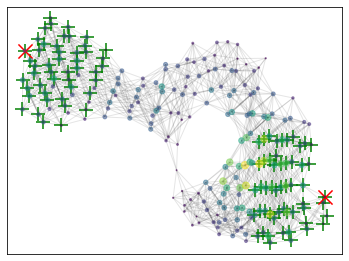

In [110]:
cv = pltext.canvas(2, 1)
cv(1)
graphfun.display_graph(graph, extremes = (u, v), blobs = blobs)